# TFT Results Analysis

This notebook analyzes the formal TFT outputs, reuses the plotting style of the earlier `c1c3_analysis.py` workflow, and saves all generated figures to `images/tft`.


In [4]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

CWD = Path.cwd().resolve()
if (CWD / "tft" / "analysis.py").exists():
    PROJECT_ROOT = CWD
elif CWD.name == "tft" and (CWD / "analysis.py").exists():
    PROJECT_ROOT = CWD.parent
else:
    raise FileNotFoundError("Could not locate project root containing tft/analysis.py")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from tft.analysis import plot_random_user_history_and_forecast, run_full_analysis


In [5]:
ARTIFACTS_DIR = PROJECT_ROOT / "tft" / "artifacts"
IMAGE_DIR = PROJECT_ROOT / "images" / "tft"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("ARTIFACTS_DIR:", ARTIFACTS_DIR)
print("IMAGE_DIR:", IMAGE_DIR)


PROJECT_ROOT: D:\MSDS\2026spring\Forecasting\Project2\Electricity-Load-Prediction
ARTIFACTS_DIR: D:\MSDS\2026spring\Forecasting\Project2\Electricity-Load-Prediction\tft\artifacts
IMAGE_DIR: D:\MSDS\2026spring\Forecasting\Project2\Electricity-Load-Prediction\images\tft


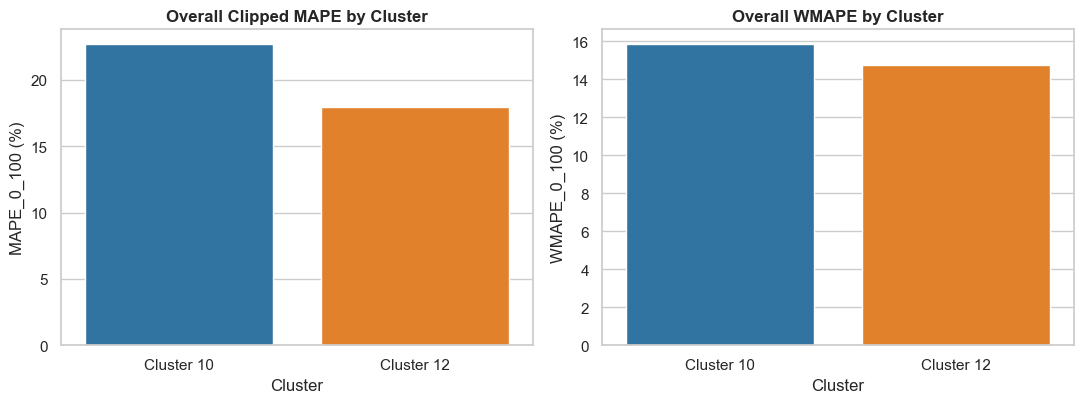

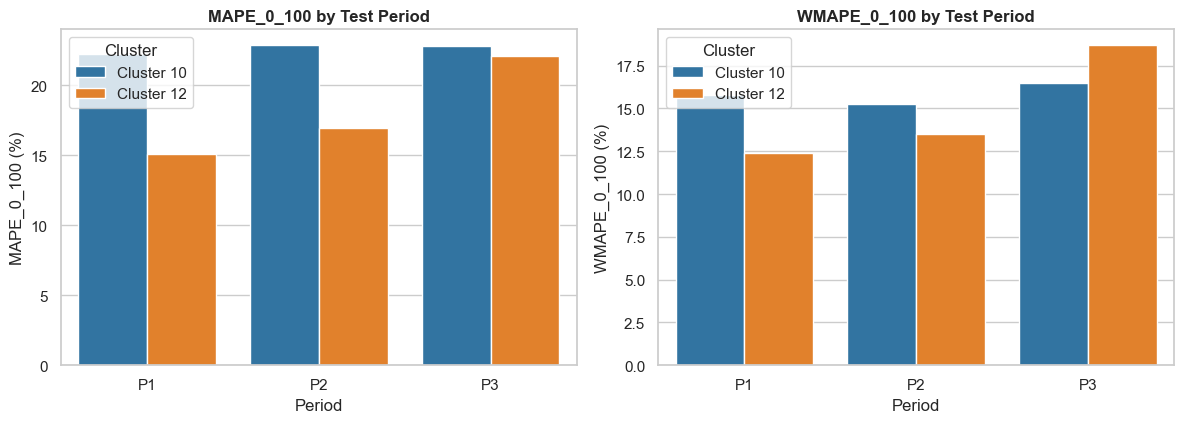

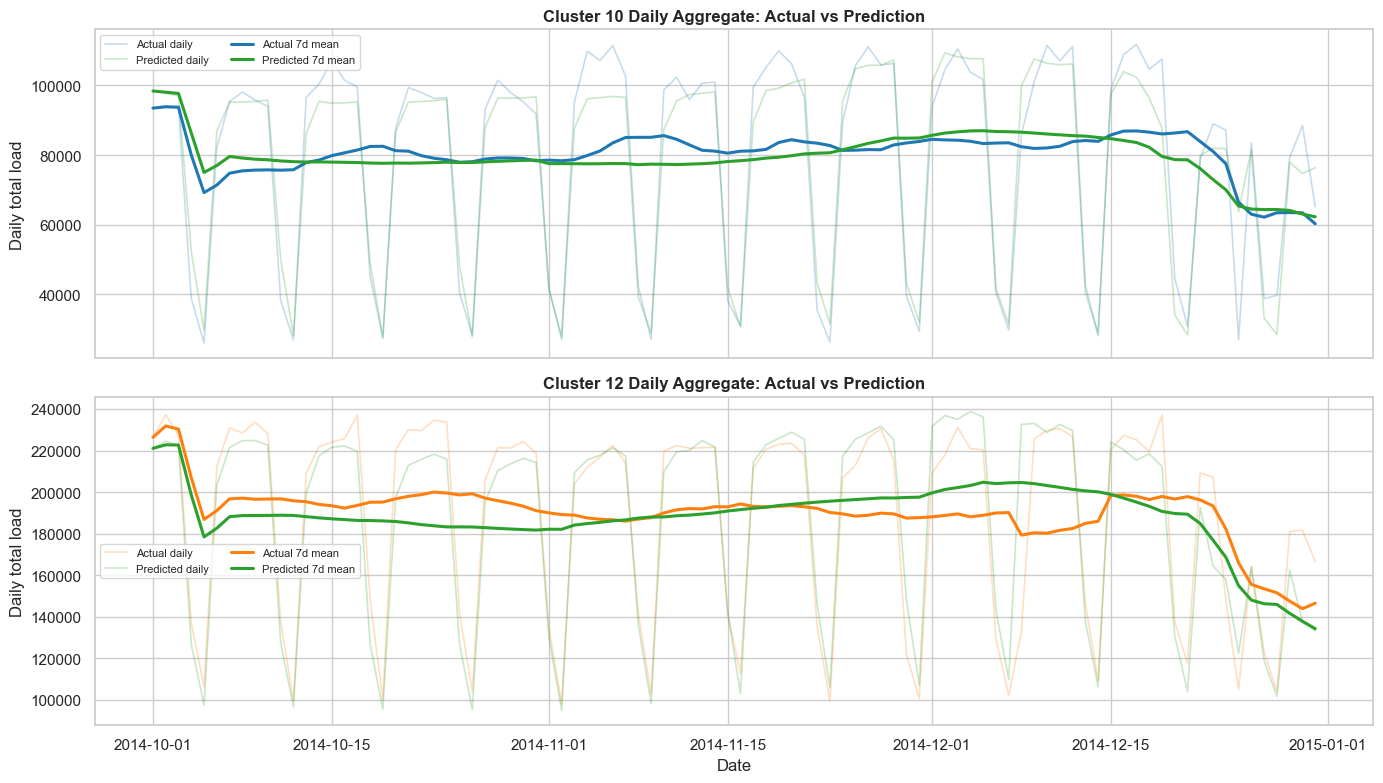

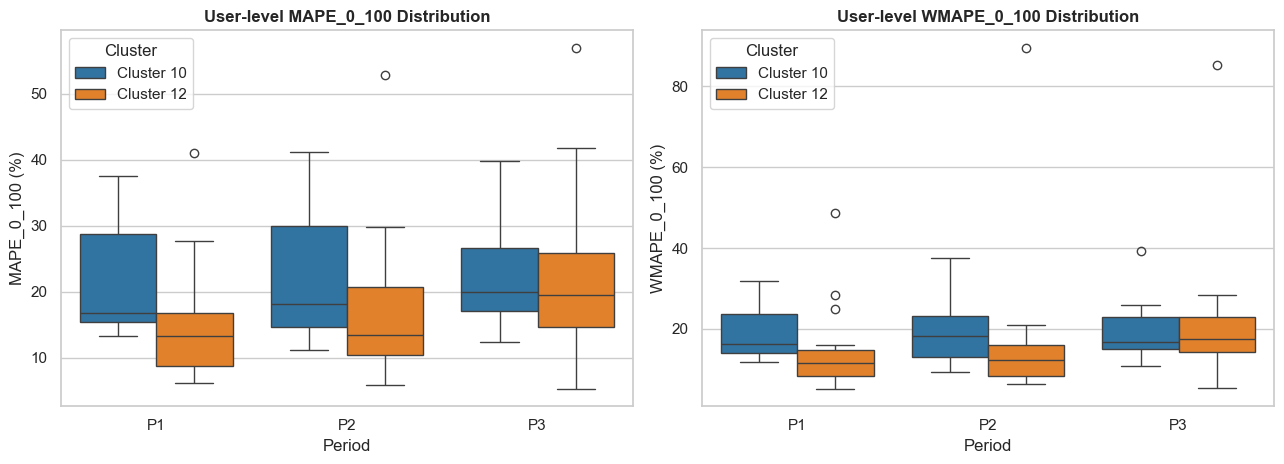

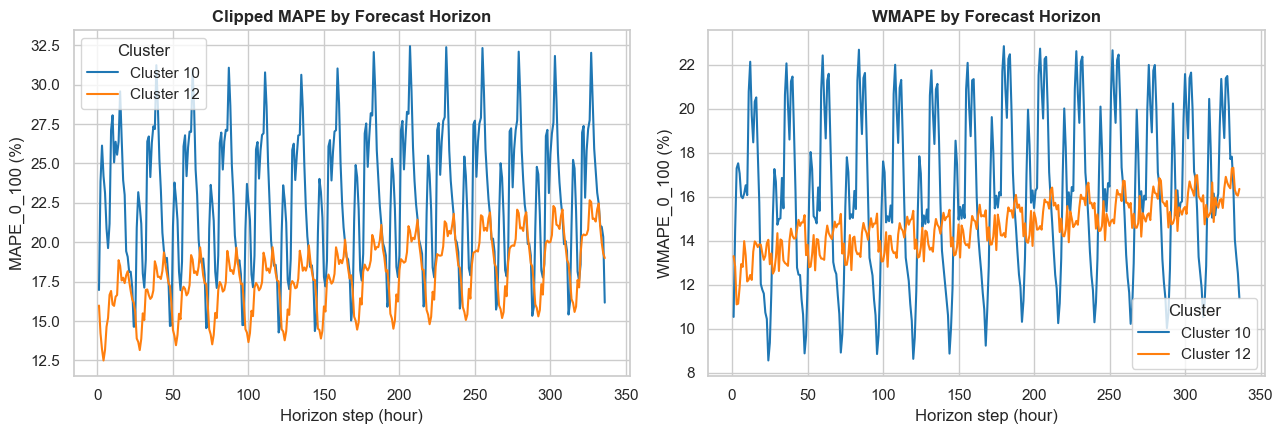

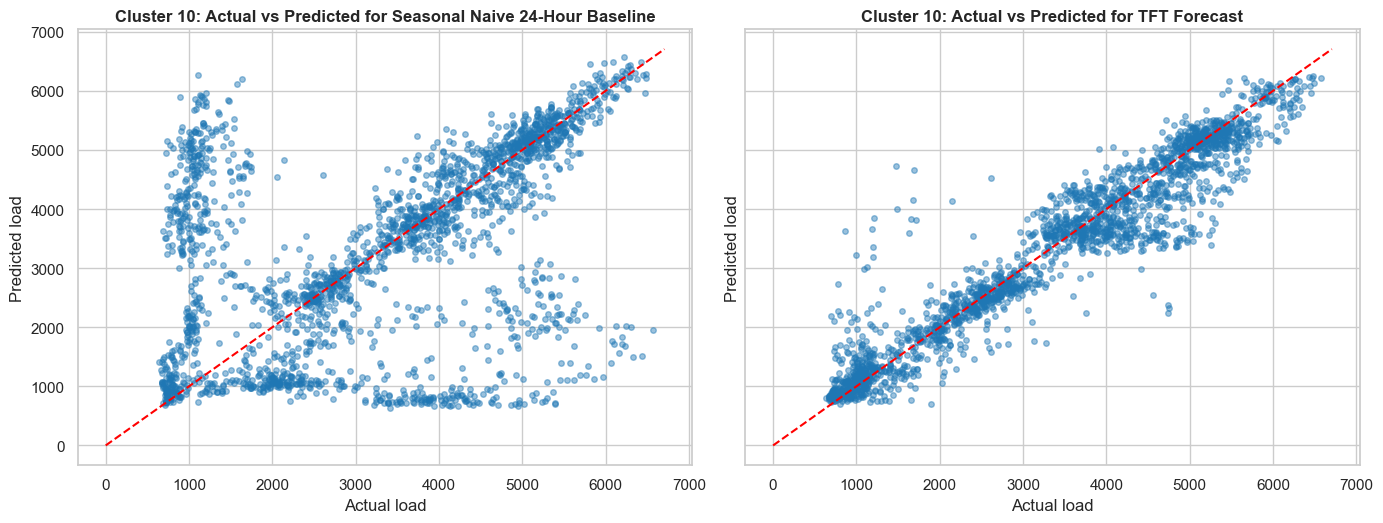

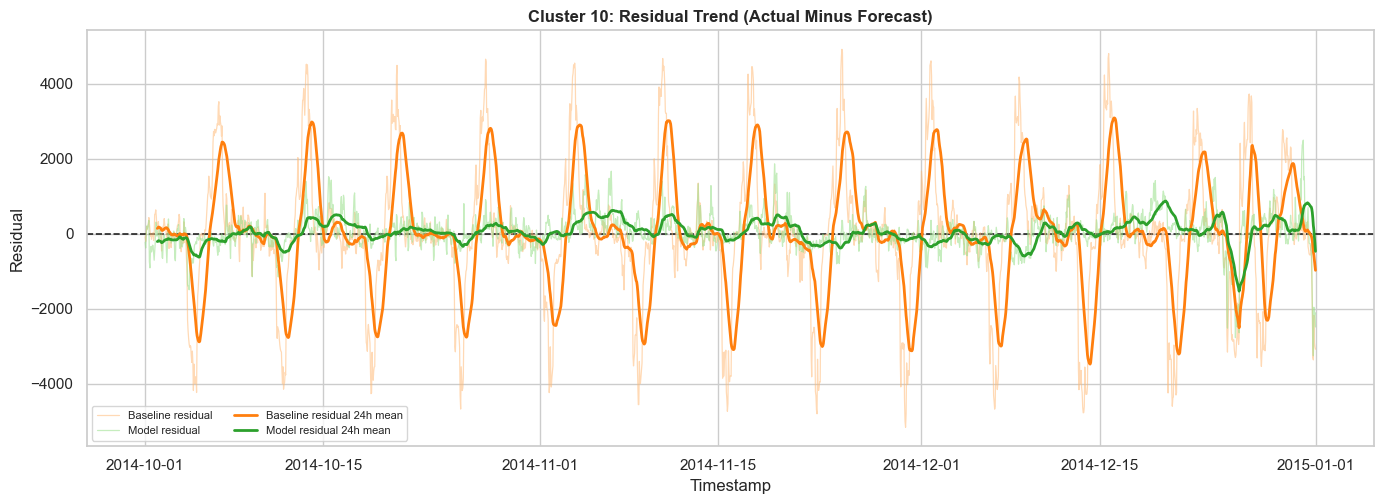

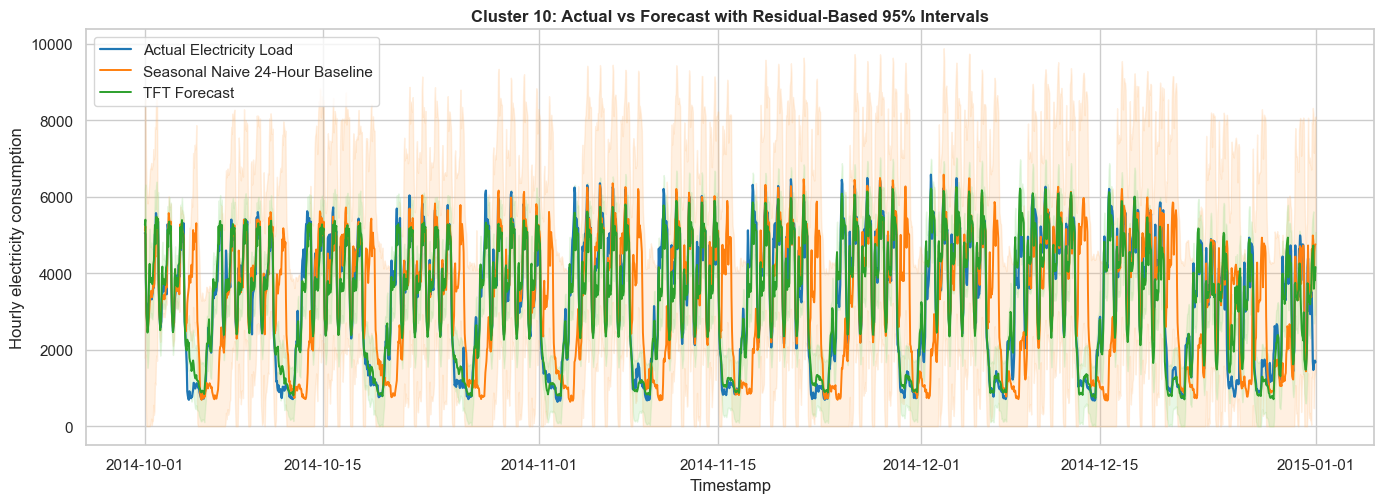

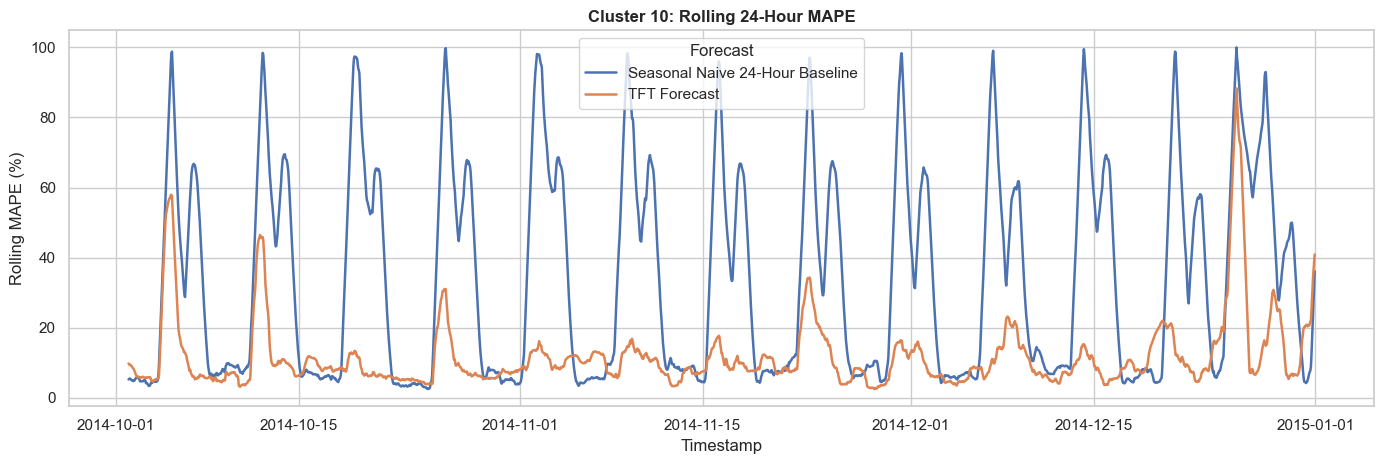

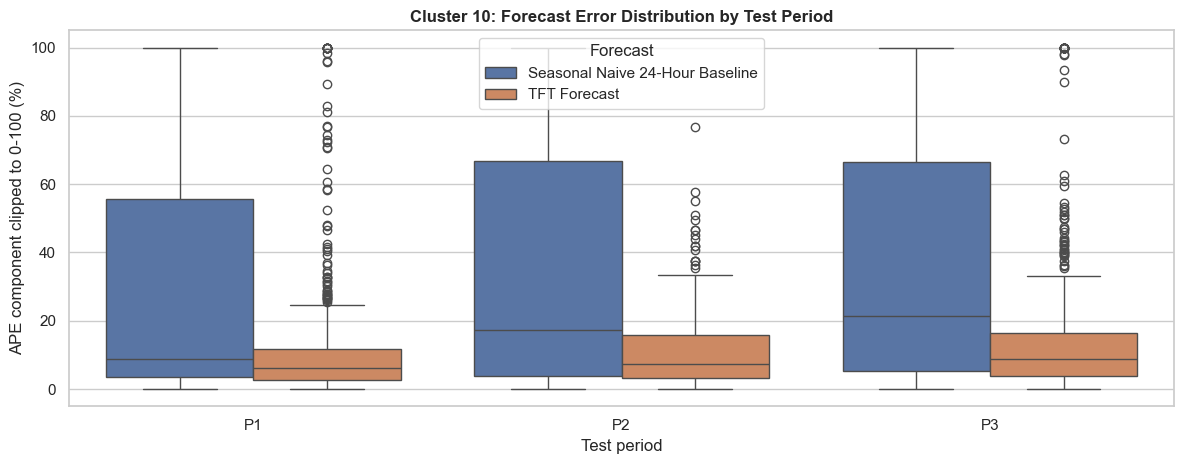

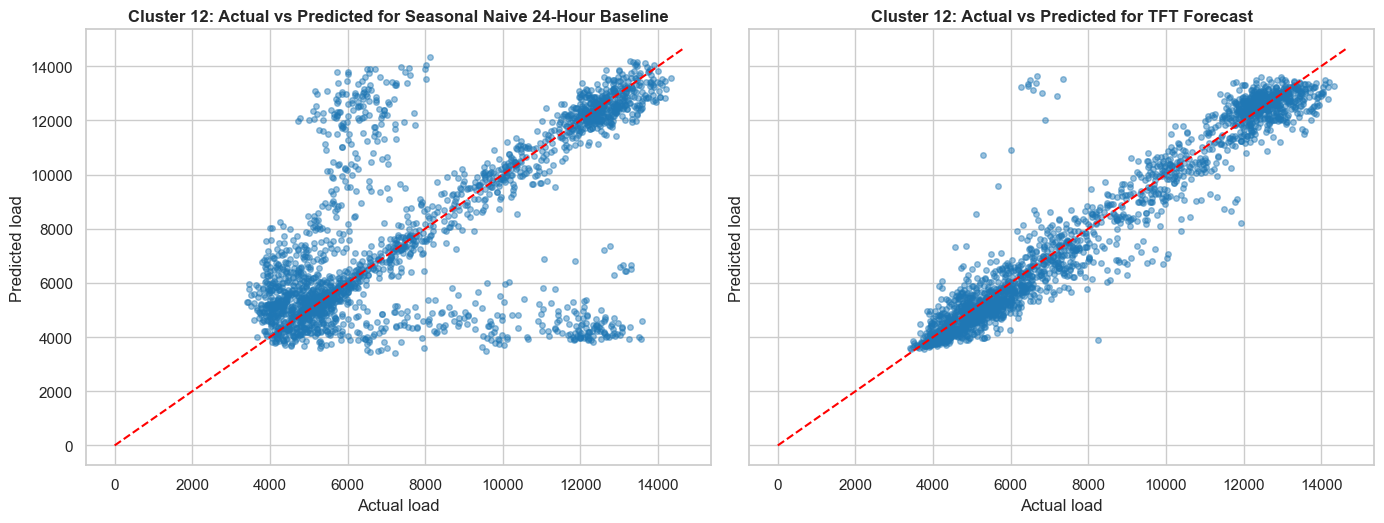

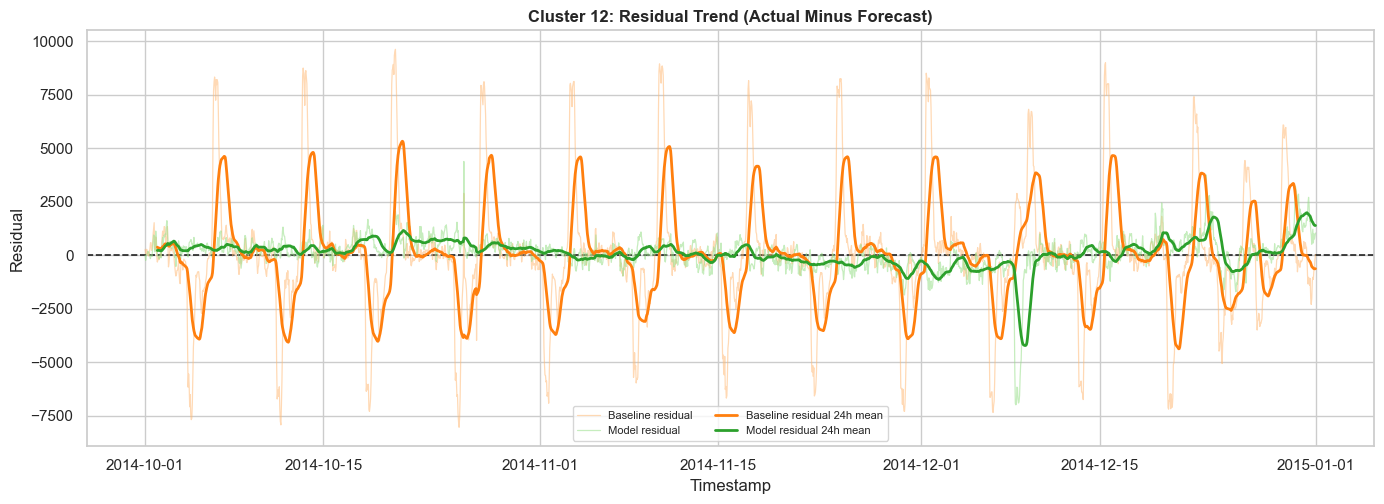

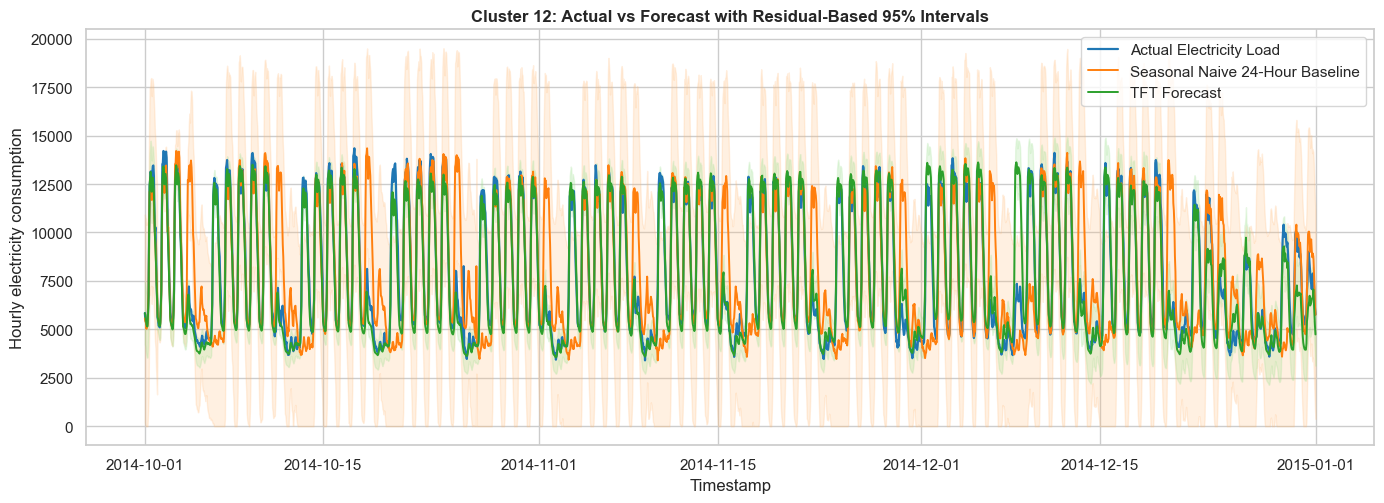

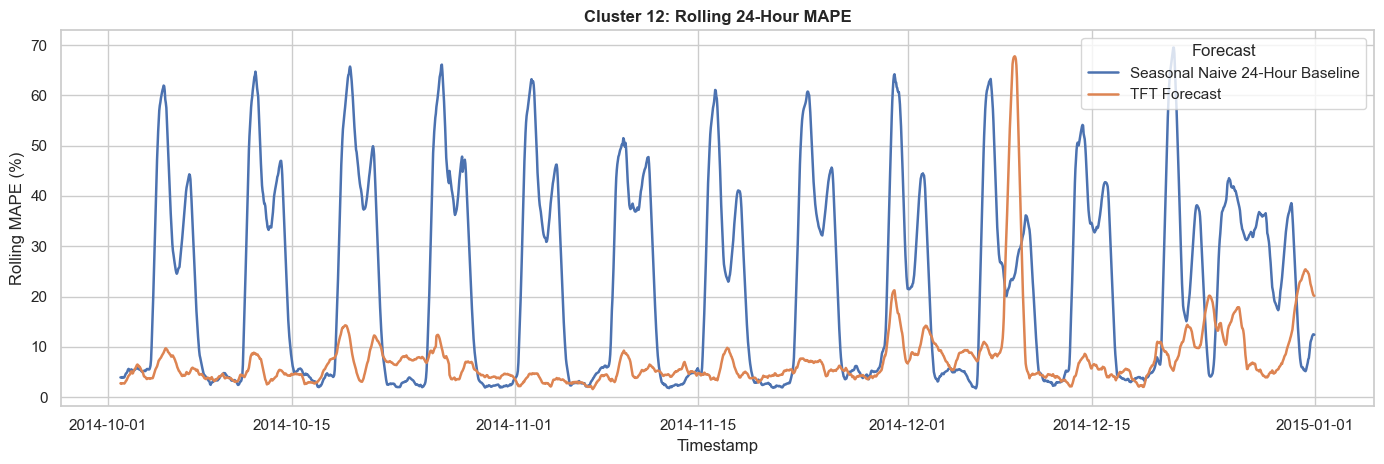

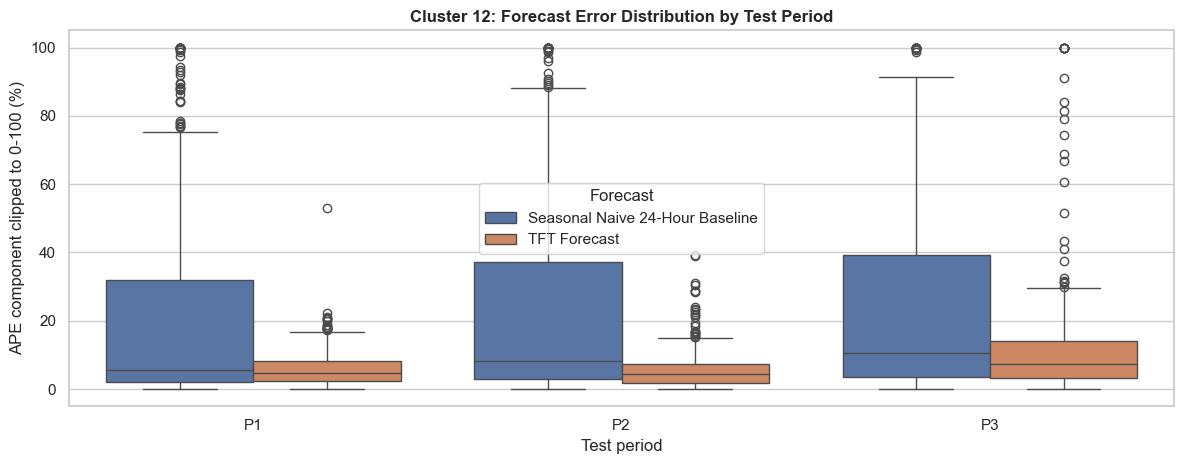

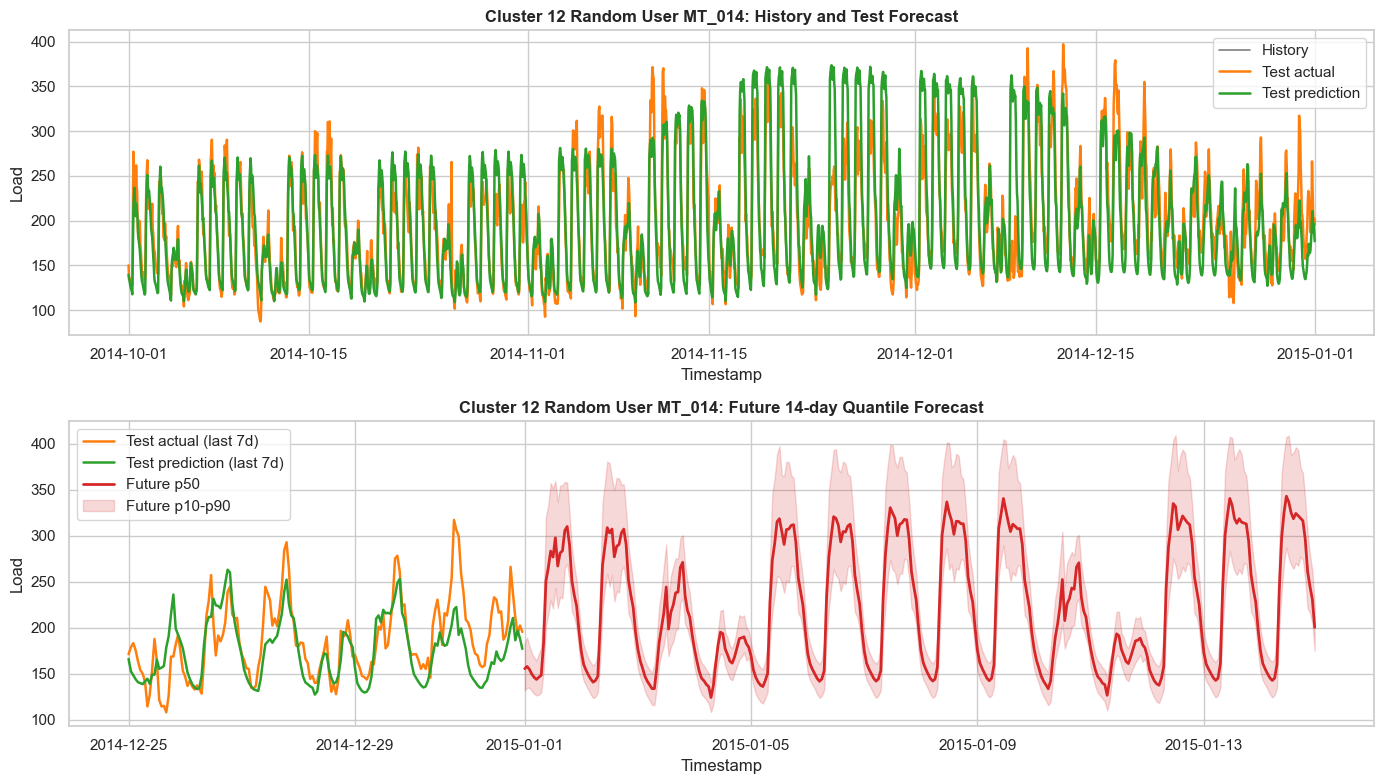

{'user_id': 'MT_014', 'cluster_id': 12}

In [6]:
bundle = run_full_analysis(
    artifacts_dir=ARTIFACTS_DIR,
    image_dir=IMAGE_DIR,
    random_seed=42,
    history_days=60,
    save_svg=False,
    show=True,
)

bundle["selected_user"]


In [7]:
display(bundle["metrics_overall"])
display(bundle["metrics_by_period"])
display(bundle["user_period_summary"])
display(bundle["cluster_period_error_summary"])


,model_name,cluster_id,period,MAPE_0_100,EPSILON_MAPE_PCT,WMAPE_0_100,n_obs,n_positive
0,tft_c10_ft,10,OVERALL,22.674136,1.867857e+06,15.824538,185808,185785
1,tft_c12_ft,12,OVERALL,17.973676,4.921227e+07,14.727217,477792,474777


,model_name,cluster_id,period,MAPE_0_100,EPSILON_MAPE_PCT,WMAPE_0_100,n_obs,n_positive
0,tft_c10_ft,10,P1,22.280342,5.335492e+06,15.796794,57624,57615
1,tft_c10_ft,10,P2,22.859432,3.340419e+01,15.280439,70560,70560
2,tft_c10_ft,10,P3,22.841038,6.873519e+05,16.494346,57624,57610
3,tft_c12_ft,12,P1,15.078702,1.763946e+06,12.402999,148176,147618
4,tft_c12_ft,12,P2,16.959472,4.114630e+07,13.485099,181440,180194
5,tft_c12_ft,12,P3,22.110534,1.065373e+08,18.683660,148176,146965


,cluster_id,period,median_MAPE_0_100,mean_MAPE_0_100,median_WMAPE_0_100,n_users
0,10,P1,16.860576,22.280342,16.318934,7
1,10,P2,18.204029,22.859432,18.280533,7
2,10,P3,19.946693,22.841038,16.766326,7
3,12,P1,13.349246,15.078702,11.681348,18
4,12,P2,13.500970,16.959472,12.398697,18
5,12,P3,19.525368,22.110534,17.574110,18


,forecast,phase,mean_ape_0_100,median_ape_0_100,p90_ape_0_100,n_obs,cluster_id
0,Seasonal Naive 24-Hour Baseline,P1,30.101195,8.775427,100.000000,744,10
1,TFT Forecast,P1,10.903370,6.126533,22.144920,744,10
2,Seasonal Naive 24-Hour Baseline,P2,35.567340,17.413721,100.000000,720,10
3,TFT Forecast,P2,10.641564,7.382609,24.744188,720,10
4,Seasonal Naive 24-Hour Baseline,P3,37.173976,21.352134,100.000000,744,10
5,TFT Forecast,P3,14.281645,8.764117,29.418022,744,10
6,Seasonal Naive 24-Hour Baseline,P1,20.961859,5.669680,66.598016,744,12
7,TFT Forecast,P1,5.801046,4.844132,11.518163,744,12
8,Seasonal Naive 24-Hour Baseline,P2,22.905111,8.323149,67.002422,720,12
9,TFT Forecast,P2,5.346702,4.325096,10.944560,720,12


In [8]:
display(bundle["horizon_metrics"].head(12))
display(bundle["daily_cluster_aggregate"].head())
display(bundle["cluster_hourly_comparison"].head())


,cluster_id,horizon_step,horizon_day,MAPE_0_100,WMAPE_0_100,n_obs
0,10,1,1,16.970418,10.536644,553
1,10,2,1,23.842798,14.426664,553
2,10,3,1,26.134745,17.297033,553
3,10,4,1,24.202179,17.523247,553
4,10,5,1,23.132593,17.057645,553
5,10,6,1,20.869271,16.023636,553
6,10,7,1,19.629929,15.935104,553
7,10,8,1,21.176438,16.143462,553
8,10,9,1,27.104463,16.522219,553
9,10,10,1,28.057084,16.075952,553


,cluster_id,date,actual,prediction,actual_roll7,prediction_roll7
0,10,2014-10-01,93444.285807,98359.015625,93444.285807,98359.015625
1,10,2014-10-02,94192.977396,97678.875000,93818.631601,98018.945312
2,10,2014-10-03,93506.494355,96924.203125,93714.585852,97654.031250
3,10,2014-10-04,38915.921651,52363.171875,80014.919802,86331.316406
4,10,2014-10-05,26028.207215,29669.875000,69217.577285,74999.028125


,cluster_id,timestamp,phase,actual,baseline_prediction,prediction,date,baseline_residual,model_residual,baseline_ape_0_100,model_ape_0_100
0,10,2014-10-01 00:00:00,P1,5046.825002,5126.898669,5269.31250,2014-10-01,-80.073667,-222.487498,1.586615,4.408465
1,10,2014-10-01 01:00:00,P1,5020.902842,5221.954872,5398.75000,2014-10-01,-201.052030,-377.847158,4.004300,7.525482
2,10,2014-10-01 02:00:00,P1,3756.839491,3758.539495,3851.90625,2014-10-01,-1.700004,-95.066759,0.045251,2.530498
3,10,2014-10-01 03:00:00,P1,3159.341828,2958.468201,2949.12500,2014-10-01,200.873626,210.216828,6.358085,6.653817
4,10,2014-10-01 04:00:00,P1,2834.276762,2721.459441,2697.21875,2014-10-01,112.817320,137.058012,3.980462,4.835731


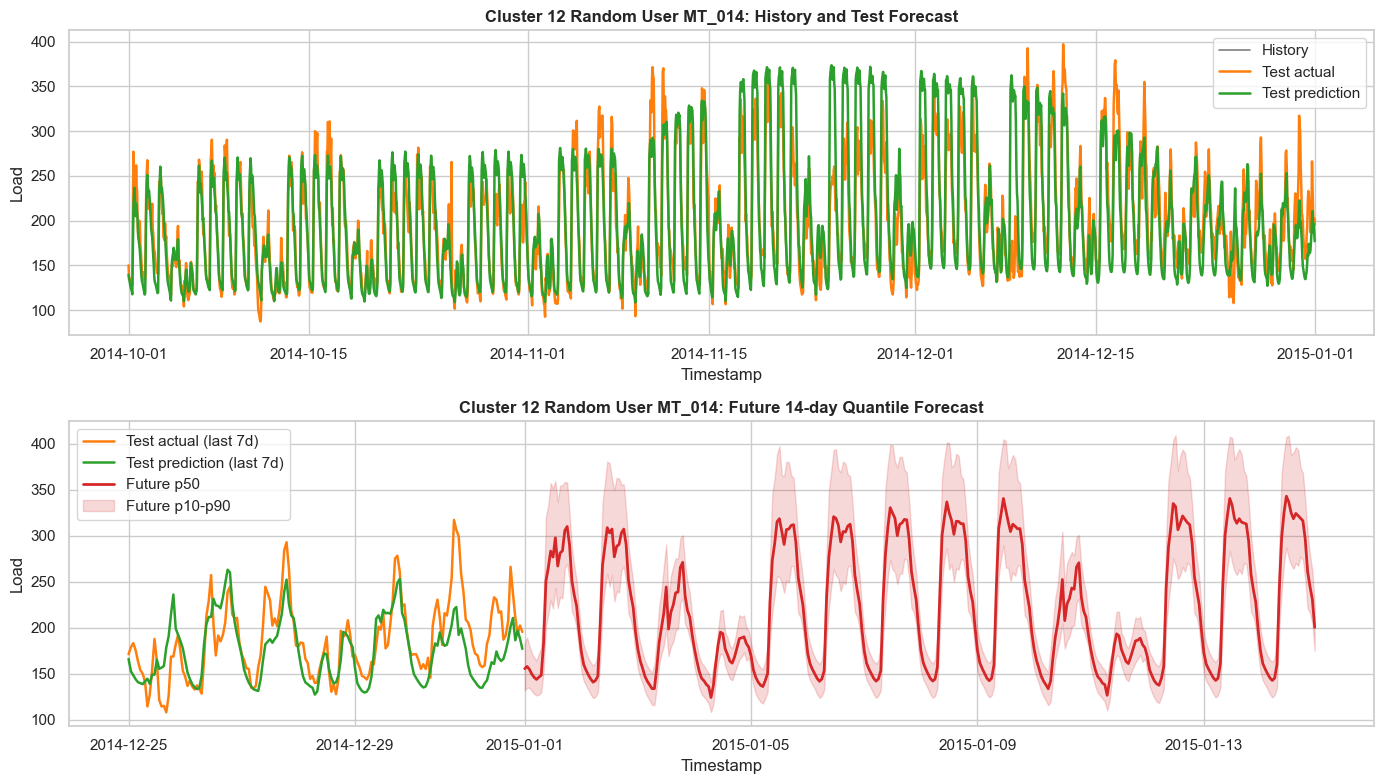

In [9]:
# Replace USER_ID with a specific meter if you want to inspect another user.
USER_ID = bundle["selected_user"]["user_id"]
CLUSTER_ID = bundle["selected_user"]["cluster_id"]

plot_random_user_history_and_forecast(
    test_user_timestamp_predictions=bundle["test_user_timestamp_predictions"],
    future_predictions=bundle["future_predictions"],
    cluster_panels=bundle["cluster_panels"],
    user_id=USER_ID,
    cluster_id=CLUSTER_ID,
    out_dir=IMAGE_DIR,
    history_days=60,
    save_svg=False,
    show=True,
)


In [10]:
sorted(path.name for path in IMAGE_DIR.glob("*"))


['01_overall_metrics.png',
 '02_period_metrics.png',
 '03_cluster_daily_aggregate.png',
 '04_user_period_distribution.png',
 '05_horizon_error_profile.png',
 '06_random_user_history_and_future.png',
 '10_cluster_10_actual_vs_forecast_intervals.png',
 '10_cluster_10_error_distribution_by_period.png',
 '10_cluster_10_residual_trend.png',
 '10_cluster_10_rolling_24h_mape.png',
 '10_cluster_10_scatter_comparison.png',
 '12_cluster_12_actual_vs_forecast_intervals.png',
 '12_cluster_12_error_distribution_by_period.png',
 '12_cluster_12_residual_trend.png',
 '12_cluster_12_rolling_24h_mape.png',
 '12_cluster_12_scatter_comparison.png']